In [2]:
from inspect_results import load_best_results, load_full_results
import numpy as np
import pandas as pd
import os
import seaborn as sns

In [2]:
all_results_df = []
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
    for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
        pattern = fr".*reweighting_rl.*energy_fn_kwargs_l_{energy_fn_kwargs_l}.*{weights_transform_fn}.*$"
        df = load_best_results(pattern, None, logdir=logdir, show_df=True)
        if df is not None:
            all_results_df.append({
                # 'weight_pre_transform_fn': weight_pre_transform_fn,
                'weights_transform_fn': weights_transform_fn,
                'mean': df['energy_mean'].mean(),
                'std': df['energy_mean'].std(),
                'se': df['energy_mean'].std() / np.sqrt(len(df)),
                'noise': 0.2,
                'energy_fn_kwargs_l': energy_fn_kwargs_l,
                'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
            })
all_results_df_sweep_initial_noise_scale = pd.DataFrame(all_results_df)


|    |   epoch |   energy_mean |   energy_std |   energy_stderr |   seed |
|---:|--------:|--------------:|-------------:|----------------:|-------:|
|  0 |     357 |      0.694624 |   0.00833096 |     8.23276e-05 |     42 |
|  1 |     360 |      0.696952 |   0.00527382 |     5.21165e-05 |     42 |
$0.696 \pm 0.002$
|    |   epoch |   energy_mean |   energy_std |   energy_stderr |   seed |
|---:|--------:|--------------:|-------------:|----------------:|-------:|
|  0 |     359 |      0.695384 |   0.00749967 |     7.41126e-05 |     42 |
|  1 |     357 |      0.692497 |   0.0113898  |     0.000112556 |     42 |
$0.694 \pm 0.002$
|    |   epoch |   energy_mean |   energy_std |   energy_stderr |   seed |
|---:|--------:|--------------:|-------------:|----------------:|-------:|
|  0 |     360 |      0.693552 |    0.0100068 |     9.88888e-05 |     42 |
|  1 |     357 |      0.690392 |    0.0143132 |     0.000141445 |     42 |
$0.692 \pm 0.002$
|    |   epoch |   energy_mean |   energy_std 

In [3]:
all_results_df_sweep_initial_noise_scale

,weights_transform_fn,mean,std,se,noise,energy_fn_kwargs_l,display
0,relu_normalize,0.695788,0.001646,0.001164,0.2,0.8,1 $\pm$ 0
1,relu_normalize,0.693941,0.002041,0.001443,0.2,1.0,1 $\pm$ 0
2,relu_normalize,0.691972,0.002235,0.001580,0.2,1.2,1 $\pm$ 0
3,relu_normalize,0.689686,0.002961,0.002094,0.2,1.4,1 $\pm$ 0
4,quad_relu_normalize,0.696952,NaN,NaN,0.2,0.8,1 $\pm$ nan
5,quad_relu_normalize,0.695384,NaN,NaN,0.2,1.0,1 $\pm$ nan
6,quad_relu_normalize,0.693552,NaN,NaN,0.2,1.2,1 $\pm$ nan
7,quad_relu_normalize,0.691780,NaN,NaN,0.2,1.4,1 $\pm$ nan
8,softmax,0.491011,NaN,NaN,0.2,0.8,0 $\pm$ nan
9,softmax,0.479326,NaN,NaN,0.2,1.0,0 $\pm$ nan


In [17]:
all_results_df = []
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
    for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
        pattern = fr".*reweighting_rl.*energy_fn_kwargs_l_{energy_fn_kwargs_l}.*{weights_transform_fn}.*$"
        df = load_full_results(pattern, logdir=logdir)
        if df is not None:
            # all_results_df.append({
            #     # 'weight_pre_transform_fn': weight_pre_transform_fn,
            #     'weights_transform_fn': weights_transform_fn,
            #     'mean': df['energy_mean'].mean(),
            #     'std': df['energy_mean'].std(),
            #     'se': df['energy_mean'].std() / np.sqrt(len(df)),
            #     'noise': 0.2,
            #     'energy_fn_kwargs_l': energy_fn_kwargs_l,
            #     'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
            # })
            print(df.head())
            df['energy_fn_kwargs_l'] = energy_fn_kwargs_l
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.2
            all_results_df.append(df)
all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
all_results_df_sweep_initial_noise_scale['regret'] = 0.7005724067912344 - all_results_df_sweep_initial_noise_scale['energy_mean']
all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300

$0.688 \pm 0.040$
   epoch  energy_mean  energy_std  energy_stderr  \
0    301     0.366228    0.175747       0.001737   
1    302     0.477976    0.178624       0.001765   
2    303     0.579333    0.132838       0.001313   
3    304     0.638781    0.079410       0.000785   
4    305     0.667542    0.046157       0.000456   

                                              logdir  
0  /home/naliseas-workstation/Documents/haitong/d...  
1  /home/naliseas-workstation/Documents/haitong/d...  
2  /home/naliseas-workstation/Documents/haitong/d...  
3  /home/naliseas-workstation/Documents/haitong/d...  
4  /home/naliseas-workstation/Documents/haitong/d...  
$0.686 \pm 0.038$
   epoch  energy_mean  energy_std  energy_stderr  \
0    301     0.386647    0.181539       0.001794   
1    302     0.491017    0.175653       0.001736   
2    303     0.589790    0.125293       0.001238   
3    304     0.644226    0.073313       0.000724   
4    305     0.672017    0.040491       0.000400   

        

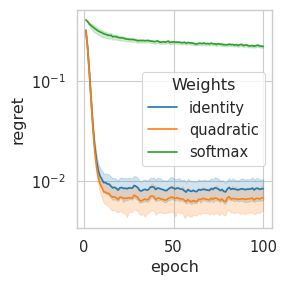

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper', font_scale=1.2)
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.lineplot(x='epoch', y='regret', data=all_results_df_sweep_initial_noise_scale, hue='weights_transform_fn', ax=ax)
h, l = ax.get_legend_handles_labels()
ax.legend(h, ['identity', 'quadratic', 'softmax'], title='Weights')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('regret_plot.pdf', dpi=300)



In [20]:
all_results_df = []
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_noise_0.1'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
    for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
        pattern = fr".*reweighting_rl.*energy_fn_kwargs_l_{energy_fn_kwargs_l}.*{weights_transform_fn}.*$"
        df = load_full_results(pattern, logdir=logdir)
        if df is not None:
            # all_results_df.append({
            #     # 'weight_pre_transform_fn': weight_pre_transform_fn,
            #     'weights_transform_fn': weights_transform_fn,
            #     'mean': df['energy_mean'].mean(),
            #     'std': df['energy_mean'].std(),
            #     'se': df['energy_mean'].std() / np.sqrt(len(df)),
            #     'noise': 0.2,
            #     'energy_fn_kwargs_l': energy_fn_kwargs_l,
            #     'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
            # })
            print(df.head())
            df['energy_fn_kwargs_l'] = energy_fn_kwargs_l
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.1
            all_results_df.append(df)
all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
all_results_df_sweep_initial_noise_scale['regret'] = 0.7005724067912344 - all_results_df_sweep_initial_noise_scale['energy_mean']
all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300

$0.691 \pm 0.039$
   epoch  energy_mean  energy_std  energy_stderr  \
0    301     0.381374    0.180219       0.001781   
1    302     0.488917    0.175261       0.001732   
2    303     0.595522    0.120912       0.001195   
3    304     0.647872    0.068989       0.000682   
4    305     0.674444    0.037058       0.000366   

                                              logdir  
0  /home/naliseas-workstation/Documents/haitong/d...  
1  /home/naliseas-workstation/Documents/haitong/d...  
2  /home/naliseas-workstation/Documents/haitong/d...  
3  /home/naliseas-workstation/Documents/haitong/d...  
4  /home/naliseas-workstation/Documents/haitong/d...  
$0.690 \pm 0.040$
   epoch  energy_mean  energy_std  energy_stderr  \
0    301     0.382535    0.180375       0.001782   
1    302     0.483425    0.177508       0.001754   
2    303     0.577828    0.133399       0.001318   
3    304     0.636335    0.081992       0.000810   
4    305     0.666513    0.047930       0.000474   

        

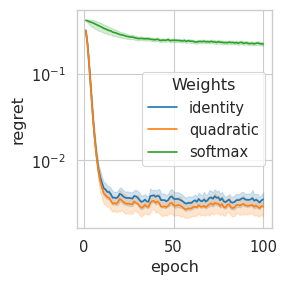

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper', font_scale=1.2)
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.lineplot(x='epoch', y='regret', data=all_results_df_sweep_initial_noise_scale, hue='weights_transform_fn', ax=ax)
h, l = ax.get_legend_handles_labels()
ax.legend(h, ['identity', 'quadratic', 'softmax'], title='Weights')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('regret_plot.pdf', dpi=300)



In [5]:
all_results_df = []
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_noise_0.05'
# for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
    for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
        pattern = fr".*reweighting_rl.*energy_fn_kwargs_l_{energy_fn_kwargs_l}.*{weights_transform_fn}.*$"
        df = load_full_results(pattern, logdir=logdir)
        if df is not None:
            # all_results_df.append({
            #     # 'weight_pre_transform_fn': weight_pre_transform_fn,
            #     'weights_transform_fn': weights_transform_fn,
            #     'mean': df['energy_mean'].mean(),
            #     'std': df['energy_mean'].std(),
            #     'se': df['energy_mean'].std() / np.sqrt(len(df)),
            #     'noise': 0.2,
            #     'energy_fn_kwargs_l': energy_fn_kwargs_l,
            #     'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
            # })
            print(df.head())
            df['energy_fn_kwargs_l'] = energy_fn_kwargs_l
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.05
            all_results_df.append(df)
all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
all_results_df_sweep_initial_noise_scale['regret'] = 0.7005724067912344 - all_results_df_sweep_initial_noise_scale['energy_mean']
all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300

$0.691 \pm 0.042$
   epoch  energy_mean  energy_std  energy_stderr  \
0    301     0.349365    0.169992       0.001680   
1    302     0.453537    0.183265       0.001811   
2    303     0.572287    0.137592       0.001360   
3    304     0.645017    0.071792       0.000709   
4    305     0.674006    0.036846       0.000364   

                                              logdir  
0  /home/naliseas-workstation/Documents/haitong/d...  
1  /home/naliseas-workstation/Documents/haitong/d...  
2  /home/naliseas-workstation/Documents/haitong/d...  
3  /home/naliseas-workstation/Documents/haitong/d...  
4  /home/naliseas-workstation/Documents/haitong/d...  
$0.692 \pm 0.038$
   epoch  energy_mean  energy_std  energy_stderr  \
0    301     0.390595    0.182107       0.001800   
1    302     0.507924    0.169827       0.001678   
2    303     0.604668    0.112974       0.001116   
3    304     0.652514    0.064013       0.000633   
4    305     0.677376    0.033321       0.000329   

        

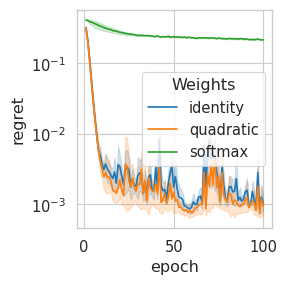

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper', font_scale=1.2)
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.lineplot(x='epoch', y='regret', data=all_results_df_sweep_initial_noise_scale, hue='weights_transform_fn', ax=ax)
h, l = ax.get_legend_handles_labels()
ax.legend(h, ['identity', 'quadratic', 'softmax'], title='Weights')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('regret_plot.pdf', dpi=300)



$0.294 \pm 0.009$
$0.675 \pm 0.076$
$0.674 \pm 0.072$
$0.672 \pm 0.070$
$0.681 \pm 0.072$
$0.680 \pm 0.069$
$0.678 \pm 0.069$
$0.677 \pm 0.069$
$0.373 \pm 0.086$
$0.410 \pm 0.057$
$0.361 \pm 0.078$
$0.402 \pm 0.039$
Weights transform fn: relu_normalize, number of unique logdirs: 4
Weights transform fn: quad_relu_normalize, number of unique logdirs: 4
Weights transform fn: softmax, number of unique logdirs: 4


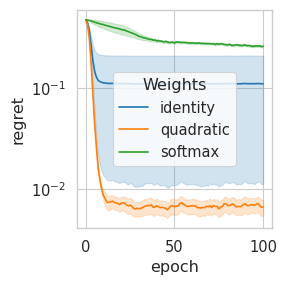

In [7]:
import matplotlib.pyplot as plt
def collect_toy_results(logdir):

    all_results_df = []
    # for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
    for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
        for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
            pattern = fr".*reweighting_rl.*energy_fn_kwargs_l_{energy_fn_kwargs_l}_{weights_transform_fn}.*$"
            df = load_full_results(pattern, logdir=logdir)
            if df is not None:
                # all_results_df.append({
                #     # 'weight_pre_transform_fn': weight_pre_transform_fn,
                #     'weights_transform_fn': weights_transform_fn,
                #     'mean': df['energy_mean'].mean(),
                #     'std': df['energy_mean'].std(),
                #     'se': df['energy_mean'].std() / np.sqrt(len(df)),
                #     'noise': 0.2,
                #     'energy_fn_kwargs_l': energy_fn_kwargs_l,
                #     'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
                # })
                # print(df.head())
                df['energy_fn_kwargs_l'] = energy_fn_kwargs_l
                df['weights_transform_fn'] = weights_transform_fn
                df['noise'] = 0.4
                all_results_df.append(df)
    all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
    all_results_df_sweep_initial_noise_scale['regret'] = 0.7005724067912344 - all_results_df_sweep_initial_noise_scale['energy_mean']
    all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300
    sns.set_context('paper', font_scale=1.2)
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    for fn in all_results_df_sweep_initial_noise_scale['weights_transform_fn'].unique():
        unique_logdirs = all_results_df_sweep_initial_noise_scale.loc[
            all_results_df_sweep_initial_noise_scale['weights_transform_fn'] == fn, 'logdir'].nunique()
        print(f"Weights transform fn: {fn}, number of unique logdirs: {unique_logdirs}")
    sns.lineplot(x='epoch', y='regret', data=all_results_df_sweep_initial_noise_scale, errorbar='se', hue='weights_transform_fn', ax=ax)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['identity', 'quadratic', 'softmax'], title='Weights')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig(os.path.join(logdir, 'regret_plot.pdf'), dpi=300)
    
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0'
collect_toy_results(logdir)


$0.294 \pm 0.009$
$0.675 \pm 0.076$
$0.674 \pm 0.072$
$0.672 \pm 0.070$
$0.681 \pm 0.072$
$0.680 \pm 0.069$
$0.678 \pm 0.069$
$0.677 \pm 0.069$
$0.373 \pm 0.086$
$0.410 \pm 0.057$
$0.361 \pm 0.078$
$0.402 \pm 0.039$
Weights transform fn: relu_normalize, number of unique logdirs: 4
Weights transform fn: quad_relu_normalize, number of unique logdirs: 4
Weights transform fn: softmax, number of unique logdirs: 4


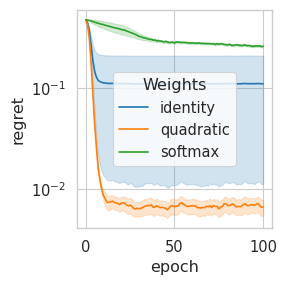

In [8]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0'
collect_toy_results(logdir)

$0.682 \pm 0.049$
$0.681 \pm 0.044$
$0.679 \pm 0.041$
$0.677 \pm 0.077$
$0.685 \pm 0.044$
$0.683 \pm 0.043$
$0.681 \pm 0.045$
$0.679 \pm 0.043$
$0.676 \pm 0.042$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3


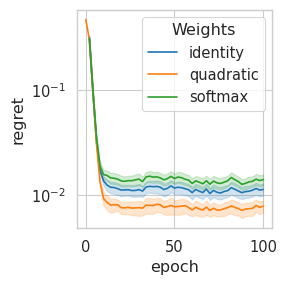

In [ ]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0_fixed_softmax'
collect_toy_results(logdir)

$0.682 \pm 0.049$
$0.681 \pm 0.044$
$0.679 \pm 0.041$
$0.687 \pm 0.042$
$0.685 \pm 0.044$
$0.683 \pm 0.043$
$0.681 \pm 0.045$
$0.679 \pm 0.043$
$0.676 \pm 0.042$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3


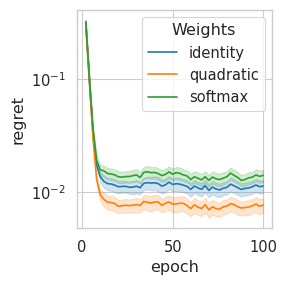

In [39]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_1.0_fixed_softmax'
collect_toy_results(logdir)

$0.682 \pm 0.049$
$0.681 \pm 0.044$
$0.679 \pm 0.041$
$0.687 \pm 0.042$
$0.684 \pm 0.044$
$0.683 \pm 0.043$
$0.681 \pm 0.045$
$0.678 \pm 0.043$
$0.676 \pm 0.042$
Weights transform fn: relu_normalize, number of unique logdirs: 4
Weights transform fn: quad_relu_normalize, number of unique logdirs: 4
Weights transform fn: softmax, number of unique logdirs: 4


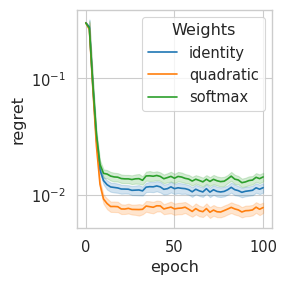

In [40]:
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_2.0_fixed_softmax'
collect_toy_results(logdir)

$0.690 \pm 0.030$
$0.690 \pm 0.046$
$0.691 \pm 0.031$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3
$0.690 \pm 0.030$
$0.693 \pm 0.031$
$0.691 \pm 0.031$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3
$0.690 \pm 0.030$
$0.693 \pm 0.031$
$0.691 \pm 0.031$
Weights transform fn: relu_normalize, number of unique logdirs: 3
Weights transform fn: quad_relu_normalize, number of unique logdirs: 3
Weights transform fn: softmax, number of unique logdirs: 3


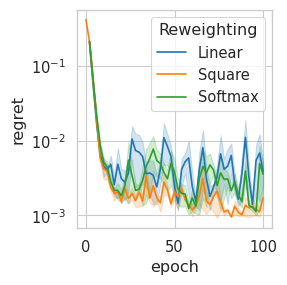

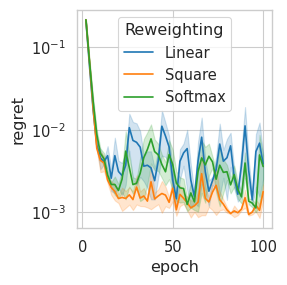

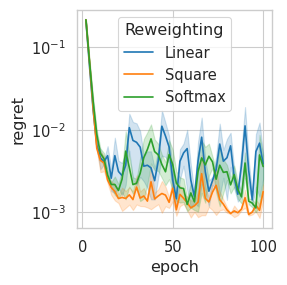

In [6]:
energy_fn_kwargs_l = 1.2
import matplotlib.pyplot as plt
def collect_toy_results(logdir, figname=None):

    all_results_df = []
    # for weight_pre_transform_fn in ["substract_min", "standarize-relu", "standarize-substract_min"]:
    for weights_transform_fn in ["relu_normalize", "quad_relu_normalize", "softmax"]:
        # for energy_fn_kwargs_l in [0.8, 1.0, 1.2, 1.4]:
        pattern = fr".*reweighting_rl.*energy_fn_kwargs_l__{weights_transform_fn}.*$"
        df = load_full_results(pattern, logdir=logdir)
        if df is not None:
            # all_results_df.append({
            #     # 'weight_pre_transform_fn': weight_pre_transform_fn,
            #     'weights_transform_fn': weights_transform_fn,
            #     'mean': df['energy_mean'].mean(),
            #     'std': df['energy_mean'].std(),
            #     'se': df['energy_mean'].std() / np.sqrt(len(df)),
            #     'noise': 0.2,
            #     'energy_fn_kwargs_l': energy_fn_kwargs_l,
            #     'display': f"{df['energy_mean'].mean():.0f} $\pm$ {df['energy_mean'].std()/ np.sqrt(len(df)) :.0f}",
            # })
            # print(df.head())
            df['energy_fn_kwargs_l'] = energy_fn_kwargs_l
            df['weights_transform_fn'] = weights_transform_fn
            df['noise'] = 0.4
            # EMA smoothing for energy_mean for each logdir
            # if 'logdir' in df.columns:
            #     ema_alpha = 0.2
            #     df = df.sort_values(['logdir', 'epoch'])
            #     df['energy_mean_smooth'] = df.groupby('logdir')['energy_mean'].transform(
            #         lambda x: x.ewm(alpha=ema_alpha, adjust=False).mean()
            #     )
            all_results_df.append(df)
    all_results_df_sweep_initial_noise_scale = pd.concat(all_results_df)
    all_results_df_sweep_initial_noise_scale['regret'] = 0.7005724067912344 - all_results_df_sweep_initial_noise_scale['energy_mean']
    all_results_df_sweep_initial_noise_scale['epoch'] = all_results_df_sweep_initial_noise_scale['epoch'] - 300
    sns.set_context('paper', font_scale=1.2)
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    for fn in all_results_df_sweep_initial_noise_scale['weights_transform_fn'].unique():
        unique_logdirs = all_results_df_sweep_initial_noise_scale.loc[
            all_results_df_sweep_initial_noise_scale['weights_transform_fn'] == fn, 'logdir'].nunique()
        print(f"Weights transform fn: {fn}, number of unique logdirs: {unique_logdirs}")
    sns.lineplot(x='epoch', y='regret', data=all_results_df_sweep_initial_noise_scale, errorbar='se', hue='weights_transform_fn', ax=ax)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Linear', 'Square', 'Softmax'], title='Reweighting')
    ax.set_yscale('log')
    plt.tight_layout()
    if figname is not None:
        plt.savefig(os.path.join(logdir, f'regret_plot_{figname}.pdf'), dpi=300)
    else:
        plt.savefig(os.path.join(logdir, 'regret_plot.pdf'), dpi=300)
    
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_1.0_fixed_softmax_v2'
collect_toy_results(logdir, figname='norm_1.0')
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_0.0_fixed_softmax_v2'
collect_toy_results(logdir, figname='norm_0.0')
logdir = '/home/naliseas-workstation/Documents/haitong/diffusion-model-hallucination/chkpts/sweep_energy_fn_kwargs_l_initial_mean_2.0_fixed_softmax_v2'
collect_toy_results(logdir, figname='norm_2.0')

ValueError: No objects to concatenate